# Watch Calibration Experiment

The watch calibration experiment serves as an extremely basic example of how to record data, analyze it, and make your experiment completely reproducible for others far into the future.

The concept of and code for this experiment is rather simple, and the focus is instead on archiving data, code, and a container that runs the code on the data using persistent identifiers

## imports

In [10]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

# import matplotlib
# matplotlib.use('TkAgg')
# plt.ion()


import copy
import os
import time 

import ipywidgets as widgets
import librosa
import numpy as np
from ipympl.backend_nbagg import Canvas
from matplotlib import pyplot as plt
from scipy import signal as sps
from scipy.io.wavfile import write

Canvas.header_visible.default_value = False

from watch_calibration import WatchCalibration
wc = WatchCalibration()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
# set environment variables
RAW_DATA_PATH = os.environ["ARTS_RAW_DATA_PATH"]

In [3]:
# prevent race condition where plots aren't showing after "Restart Kernel and Run All Cells" is selected
time.sleep(.5)

# suppress warning about too many open figures
plt.rcParams.update({'figure.max_open_warning': 0})

In [4]:
# close all open plots to free up memory
plt.close('all')

# data collection

In [5]:
# show all system audio inputs and outputs
wc.query_devices()

  0 MacBook Pro Microphone, Core Audio (1 in, 0 out)
  1 MacBook Pro Speakers, Core Audio (0 in, 2 out)
* 2 0_full, Core Audio (4 in, 4 out)
  3 ZoomAudioDevice, Core Audio (2 in, 2 out)


In [18]:
# audio recording parameters

# use system defaults; can change to int values above corresponding to specific interfaces
INPUT_DEVICE = None
OUTPUT_DEVICE = None

wc.fs = 44100  # Sample rate

# audio_file = "output-5m.wav"
# audio_file = "output-1m.wav"
# audio_file = "data_W241130_W241130.wav"
audio_file = f"../{RAW_DATA_PATH}/data5m_W250227_W250227.wav"
# audio_file = "data_W250227_W250227.wav"

In [55]:
def recreate_dataset(generate=True, duration=60):
    """Create new data set from scratch.
        generate
        duration
    """

    wc.save_audio_to_file(duration, input_device=INPUT_DEVICE, generate=generate)

# recreate_dataset(generate=False, duration=5*60)

# play audio file
# wc.play_audio(audio_file, output_device=OUTPUT_DEVICE)

## data viewing

In [19]:
def load_audio(audio_file, duration_sec=None, last=False):
    # load audio
    watch_audio, _ = wc.load_audio(audio_file)    
    if duration_sec:
        if last:
            # return only last duration_sec of audio
            watch_audio = watch_audio[:wc.fs*duration_sec]
        else:
            # return only first duration_sec of audio
            watch_audio = watch_audio[:wc.fs*duration_sec]
    return watch_audio


watch_audio = load_audio(audio_file)

### plot time and frequency signal

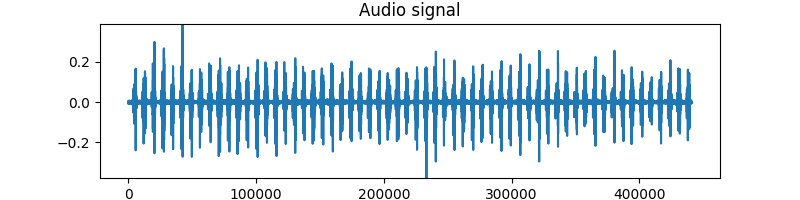

13230000
HERE
[11718 13520 14422 14693 14808 15325 16220 17128 17642 18009 18366 18935
 19831 21620]


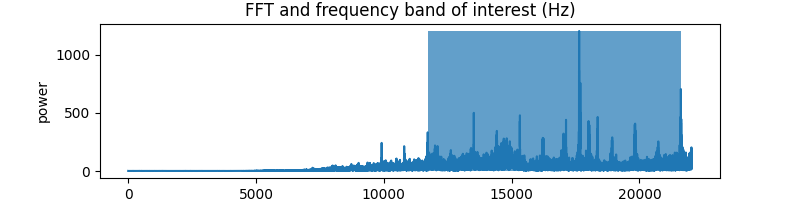

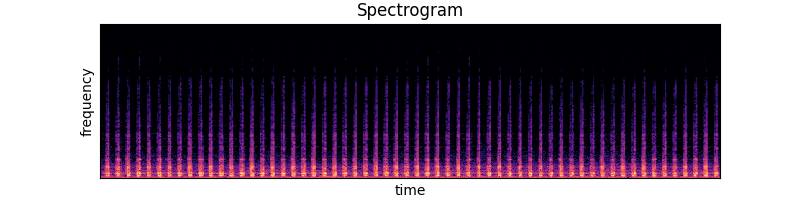

In [20]:
PLT_SECS = 10 

# plot last PLT_SECS seconds of time signal and spectrogram; plot full fft 
wc.plot_audio(watch_audio, plt_secs=PLT_SECS)

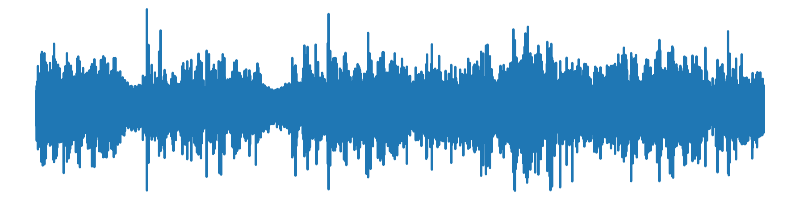

In [155]:
wc.generate_figures(watch_audio)

## Analysis

### Background

The goal of this analysis is to determine the clock drift of the watch measured in the supplied audio recording. By clock drift here, we mean the amount per unit time that the watch will differ from an ideal clock with an invariant tick frequency. In order to calculate clock drift, we first need to reliably determine the time at which the watch ticks.

There a number of ways to pick out clock ticks from an audio waveform, but the basic idea is to pinpoint where all the clock ticks happen by looking at the waveform and where it peaks in amplitude, calculate the time between the first and last ticks of the recording, and compare it to the time that would be taken by an ideal tick frequency from the first tick of the recording. This assumes that the clock ticks are ideally tuned to a specific frequency (in this case, 6 Hz) which generates a 1 Hz second.

### Manual method

A fairly manual method to achieve this using Audacity can be found [here](https://www.instructables.com/Calibrate-a-Mechanical-Watch-Using-Sound-Waves/) which includes amplification of the signal, noise reduction, the generation of an ideal click track, alignment of the intial peaks, and measurement of the timing difference between final peaks. Once the difference is measured, the clock drift is simply the difference divided by the unit time over which the drift is measured.

### Automated method

To automate this, we make use of the `scipy.signal.find_peaks` and `numpy.correlate` functions. 

This method is implemeted by the `WatchCalibration.perform_analysis` method which calls ...

```
find_peaks
block out sets
make sure there is a window for each one
cross correlation
hilbert transform
re run across entire set
do stats

fit template to peak (template matching)
convex hull -> hilbert transform
run a cross correlation
```

In [83]:
wc.perform_analysis(watch_audio)

first click time: 0.2429 s
actual last click time: 59.4089
ideal last click time: 59.4096
0.00075 s drift in a minute
1.08 s drift in a day
7.58 s drift in a week
32.51 s drift in a month (30 days)
6.59 m drift in a year (365 days)


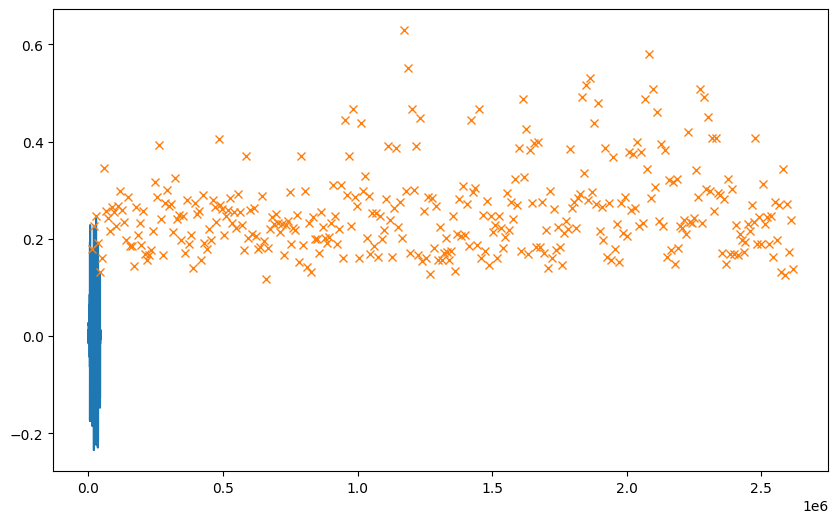

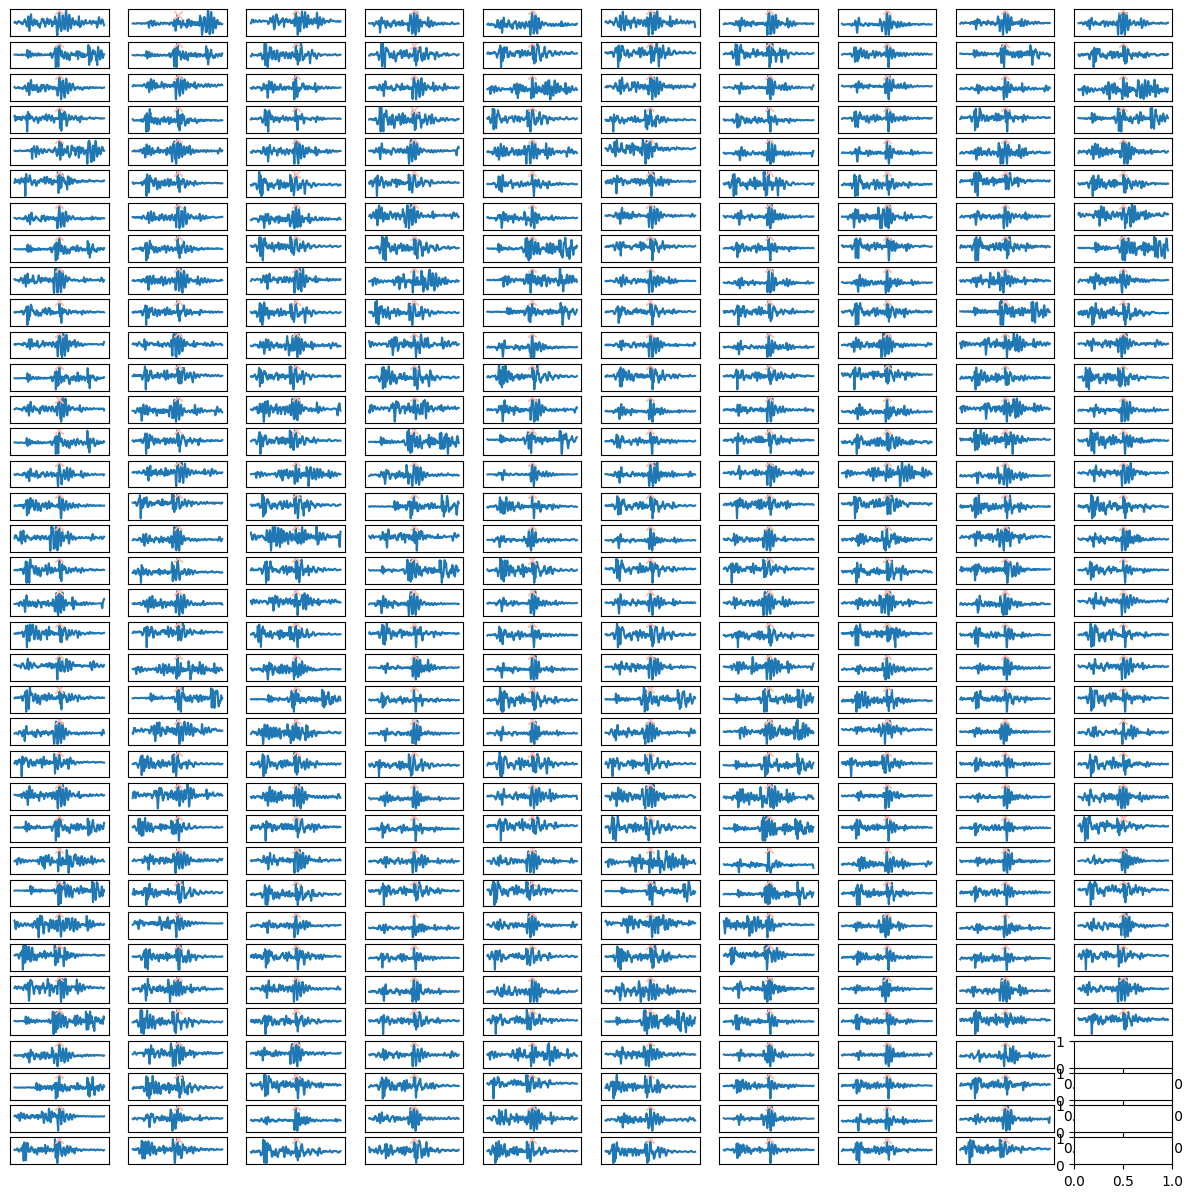

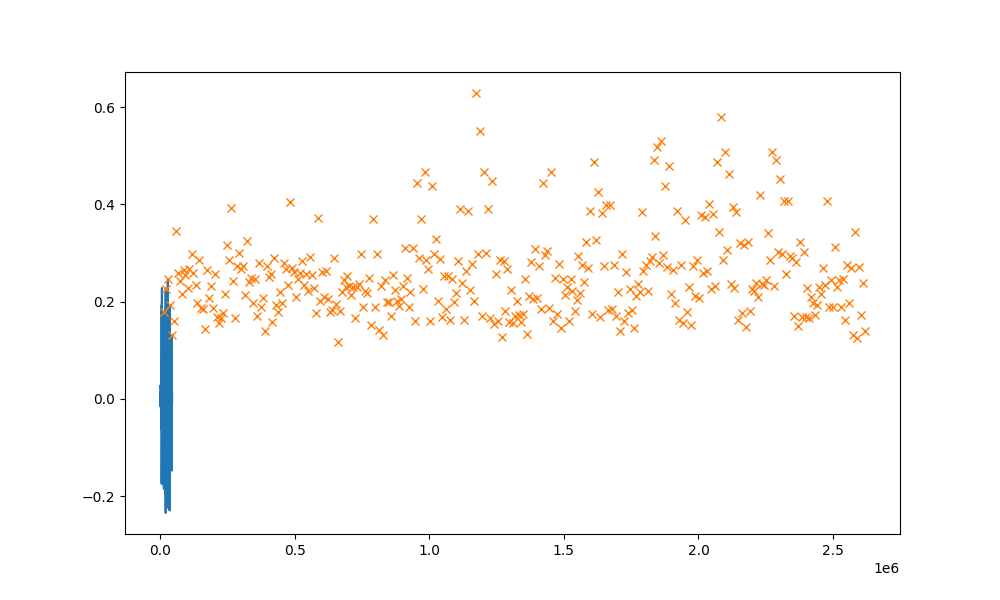

In [104]:
display(wc.view_correlations(watch_audio))

In [ ]:
display(wc.view_correlations(watch_audio, shift=True))

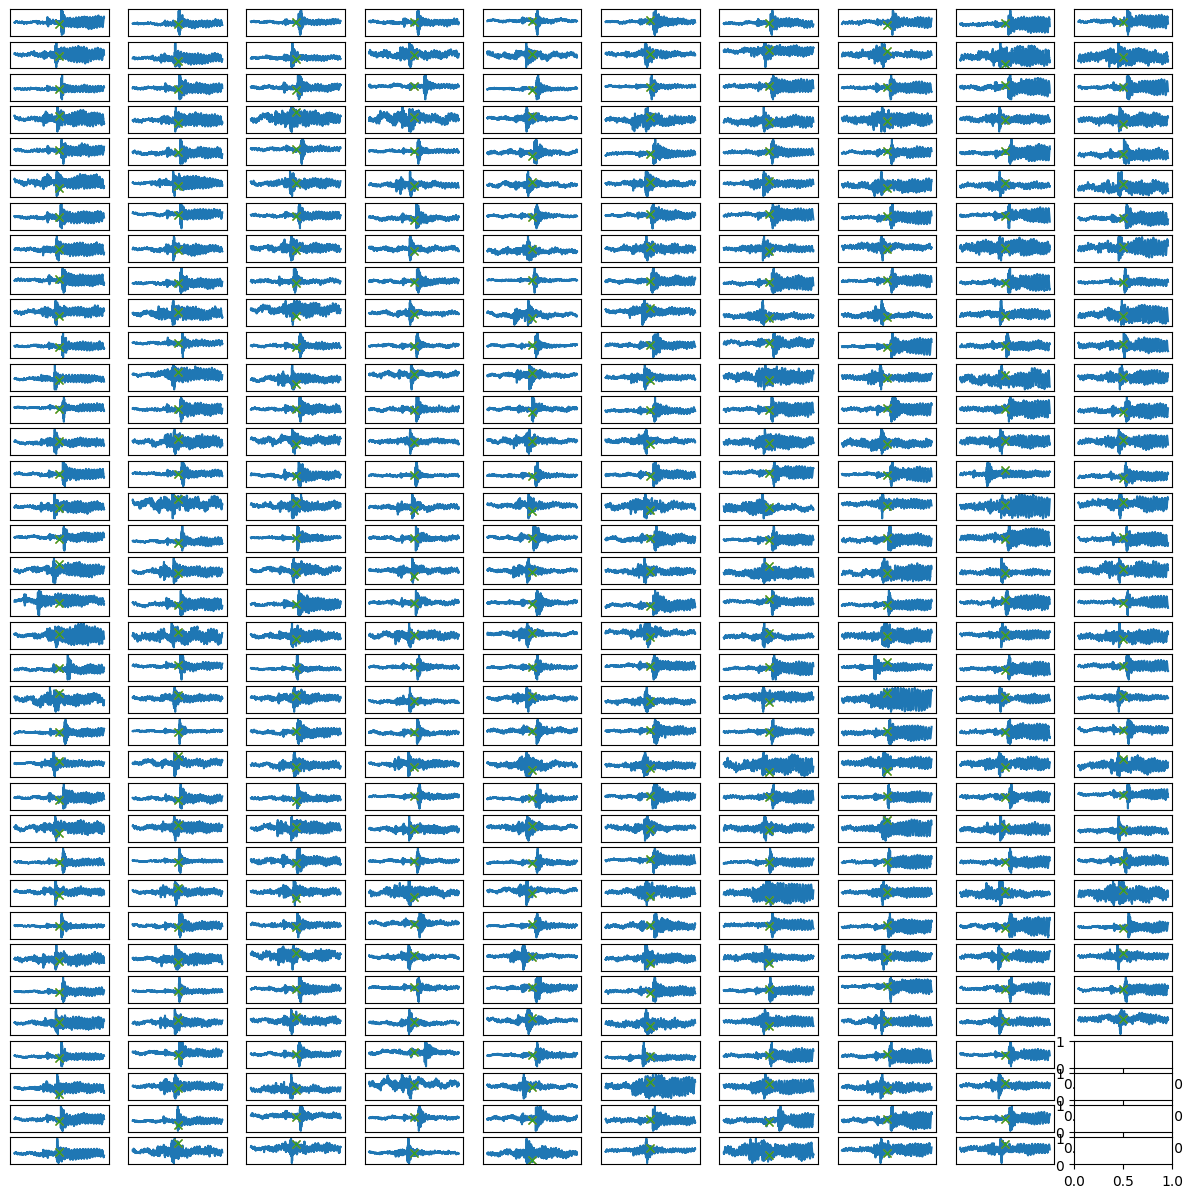

In [70]:
display(wc.view_correlations(watch_audio, hilbert=True))

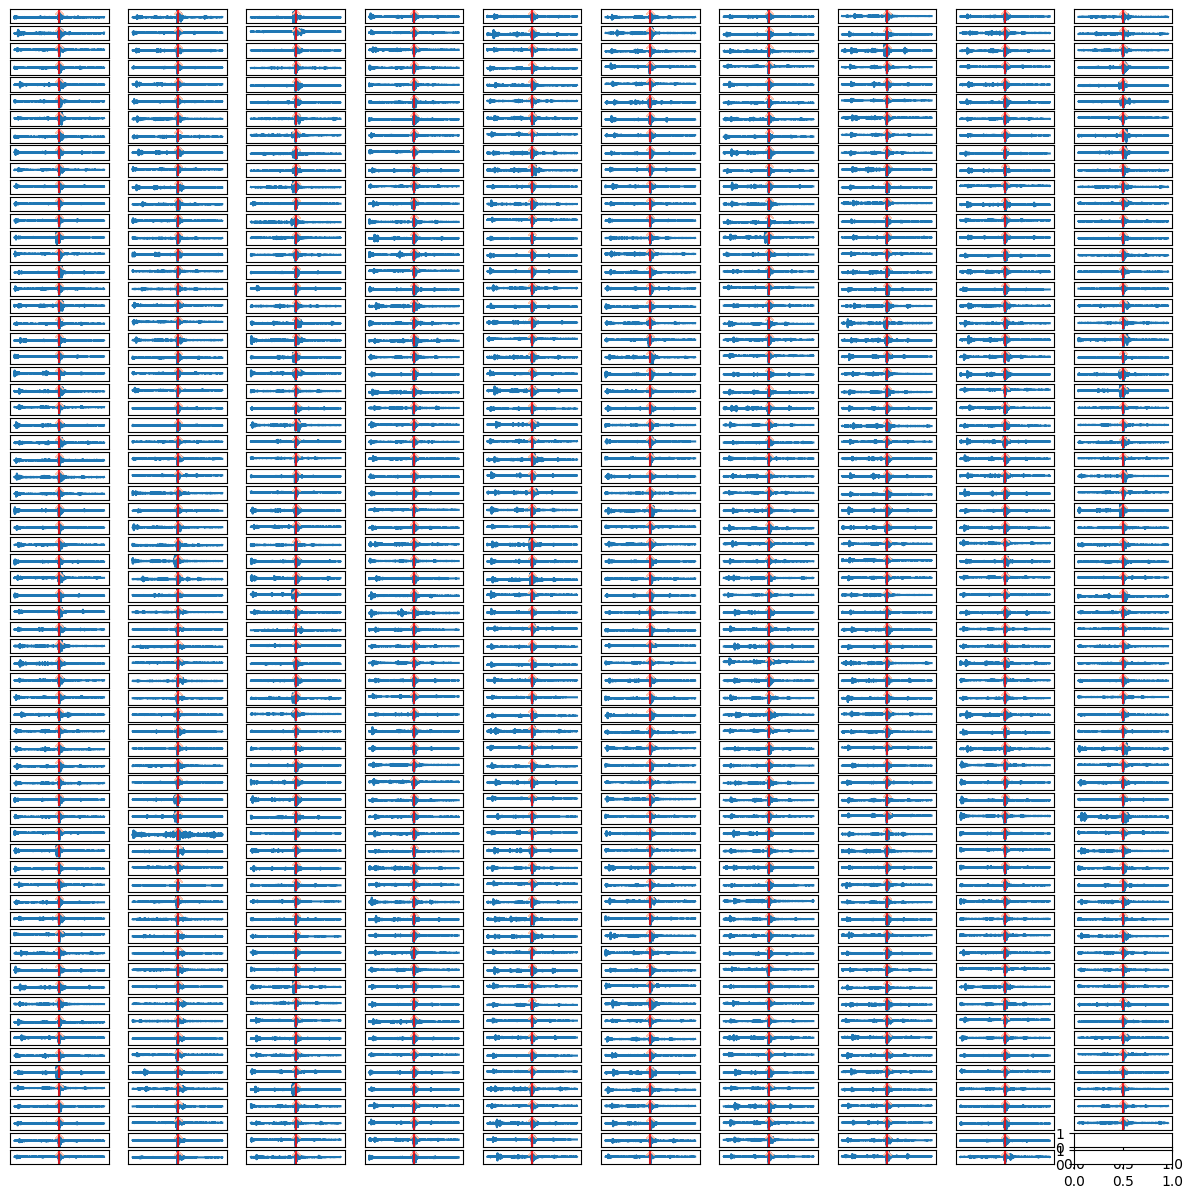

In [46]:
display(wc.view_correlations(watch_audio, envelope=True))

### match peaks with cross-correlation

FloatSlider(value=0.0, max=297.6666666666667)

1796


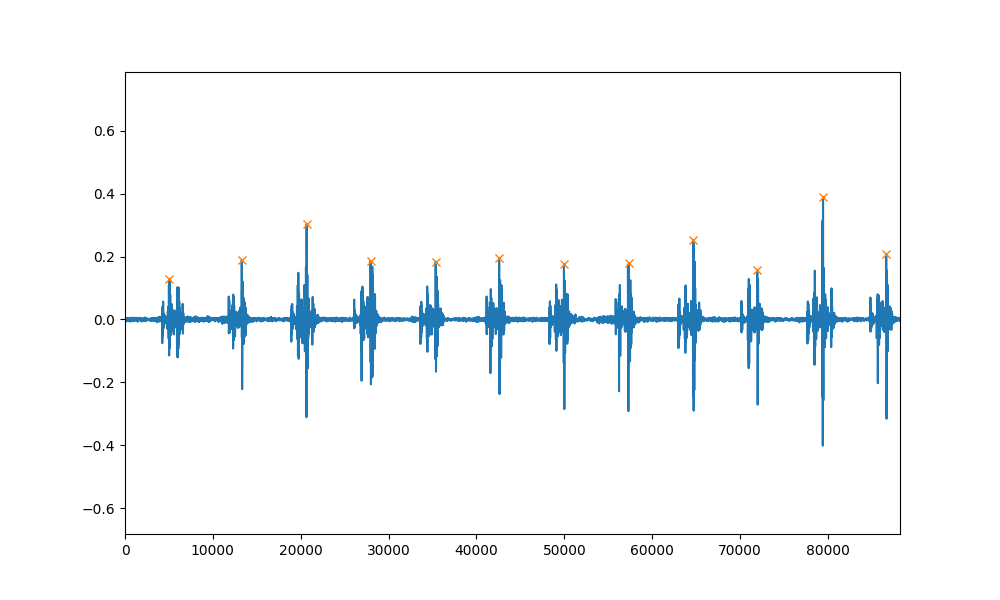

In [74]:

FREQ_GUESS = 6.
WINDOW_LEN = 2000
PEAK_PROMINENCE = 0.003


distance = int(wc.fs/FREQ_GUESS*.9)
win_size = int(wc.fs/FREQ_GUESS)
comp_audio = watch_audio[win_size:-win_size]
    
def plot_peaks(x, peaks):
    if len(x) > wc.fs * 2:
        fig, ax = plt.subplots(figsize=(10,6))
        ax.plot(x)
        ax.plot(peaks, x[peaks], "x")
        ax.set_xlim(0,wc.fs*2)
        
        slider = widgets.FloatSlider(value=0, max=len(x)/wc.fs-2, step=0.1, continuous_update=True)
        def update(change):
            ax.set_xlim(change.new*wc.fs, (change.new+2)*wc.fs)
            fig.canvas.draw_idle() 
        slider.observe(update, names='value')
    
        display(slider)
    

def plot_proms(audio):
    peaks = sps.find_peaks(audio, distance=distance, prominence=PEAK_PROMINENCE, wlen=distance)[0]
    prominences = sps.peak_prominences(audio, peaks, wlen=distance)[0]
    plot_peaks(audio, peaks)
    # throw out first and last peaks
    return peaks[1:-1], prominences[1:-1]

peaks, prominences = plot_proms(comp_audio)
print(len(peaks))


### cross-correlate signal envelopes

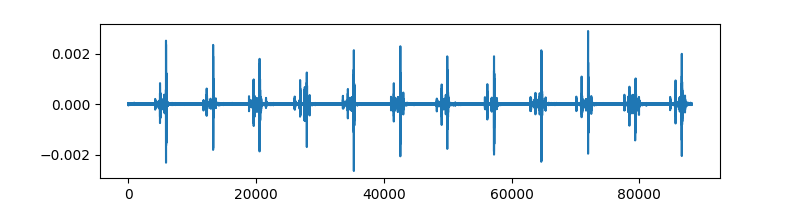

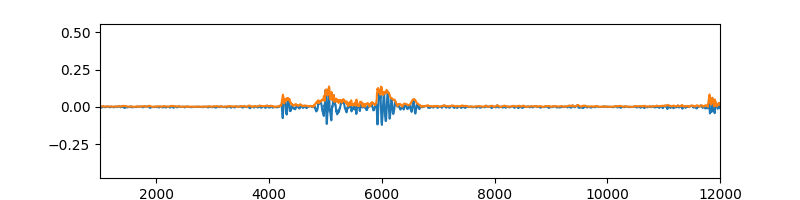

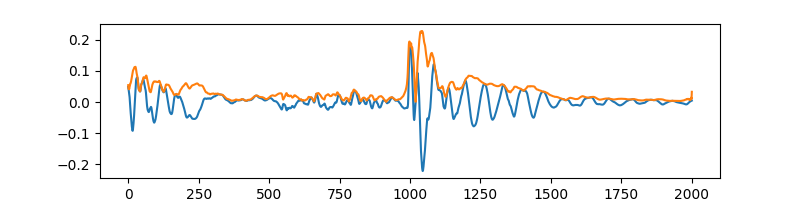

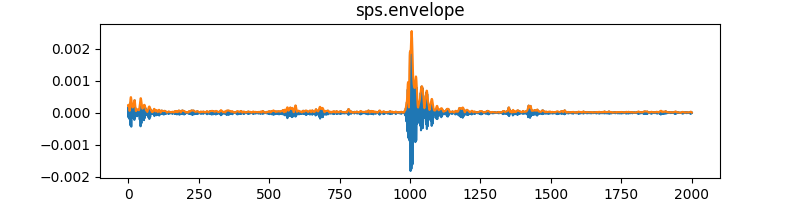

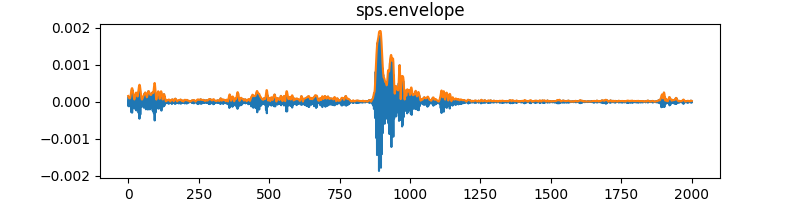

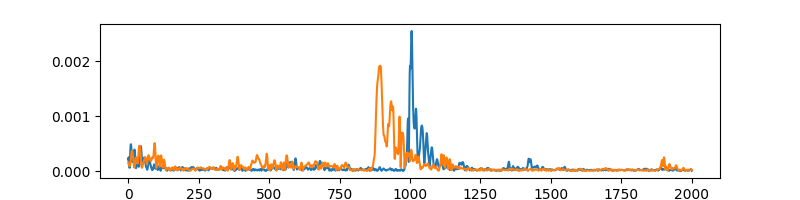

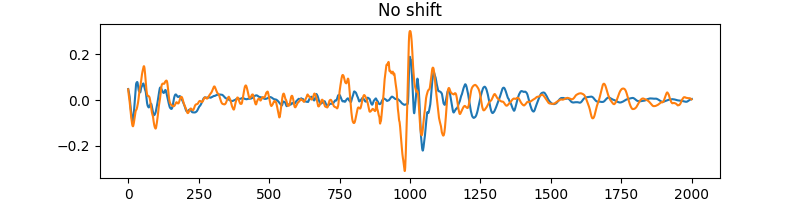

/Users/sabard/.pyenv/versions/3.10.14/envs/watch-calibration/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/sabard/.pyenv/versions/3.10.14/envs/watch-calibration/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


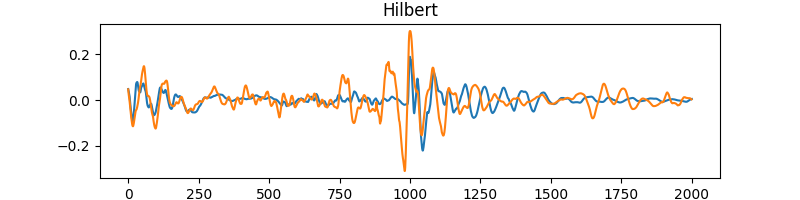

NameError: name 'corr_wins' is not defined

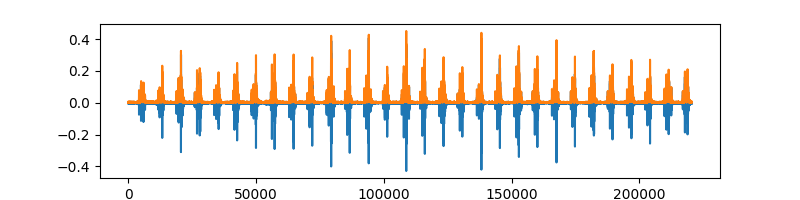

In [79]:
# more robust ways to cross-correlate
import scipy
def calculate_envelope(x):
        A = np.abs(scipy.fft.fft(x))[:wc.fs//2]
        peaks = sps.find_peaks(
            A, height=np.mean(A)*8, distance=wc.fs//400
        )[0]
        freq_band = (peaks[0], peaks[-1])
        b, a = sps.butter(6, freq_band, btype="bandpass", fs = wc.fs)
        filtered = sps.filtfilt(b, a, x)
        z_env, z_res = sps.envelope(filtered)
        return filtered, z_env

filtered_audio, envelope = calculate_envelope(comp_audio)

fig = plt.figure(figsize=(8,2))
fig.canvas.header_visible = False
plt.plot(filtered_audio[:wc.fs*2])
plt.show()

# hilbert transform -> envelope signal
i0 = 0
i1 = 1
win1 = comp_audio[peaks[i0]-WINDOW_LEN//2:peaks[i0]+WINDOW_LEN//2 + 1]
filt_win1 = filtered_audio[peaks[i0]-WINDOW_LEN//2:peaks[i0]+WINDOW_LEN//2 + 1]
win2 = comp_audio[peaks[i1]-WINDOW_LEN//2:peaks[i1]+WINDOW_LEN//2]
env1 = envelope[peaks[i0]-WINDOW_LEN//2:peaks[i0]+WINDOW_LEN//2 + 1]
env2 = envelope[peaks[i1]-WINDOW_LEN//2:peaks[i1]+WINDOW_LEN//2 + 1]
h1 = sps.hilbert(win1)
h2 = sps.hilbert(win2)

fig = plt.figure(figsize=(8,2))
fig.canvas.header_visible = False
plt.plot(comp_audio[:wc.fs*5])
plt.plot(np.abs(sps.hilbert(comp_audio[:wc.fs*5])))
plt.xlim(1000,12000)
plt.show()

fig = plt.figure(figsize=(8,2))
fig.canvas.header_visible = False
plt.plot(win1)
plt.plot(np.abs(h1))
plt.show()

def plot_envelope(filtered, envelope, x_range):
    filt_win = filtered[x_range[0]:x_range[1]]
    fig = plt.figure(figsize=(8,2))
    fig.canvas.header_visible = False
    plt.plot(filt_win)
    # envelope, z_res = sps.envelope(filt_win1, bp_in=(1,7700), residual="all")
    # b, a = sps.butter(8, 200, btype="lowpass", fs=wc.fs)
    # plt.plot(sps.filtfilt(b, a, win1))
    plt.plot(envelope[x_range[0]:x_range[1]])
    plt.title("sps.envelope")
    plt.show()

plot_envelope(filtered_audio, envelope, (peaks[i0]-WINDOW_LEN//2,peaks[i0]+WINDOW_LEN//2 + 1))
plot_envelope(filtered_audio, envelope, (peaks[i1]-WINDOW_LEN//2,peaks[i1]+WINDOW_LEN//2 + 1))

fig = plt.figure(figsize=(8,2))
fig.canvas.header_visible = False
env1 = envelope[peaks[i0]-WINDOW_LEN//2:peaks[i0]+WINDOW_LEN//2 + 1]
env2 = envelope[peaks[i1]-WINDOW_LEN//2:peaks[i1]+WINDOW_LEN//2 + 1]
plt.plot(env1)
plt.plot(env2)
plt.show()


fig = plt.figure(figsize=(8,2))
fig.canvas.header_visible = False
wfm = comp_audio[:wc.fs*5]
alpha=0.92
out = [0]
for sample in wfm:
    out.append(max(np.abs(sample), alpha*out[-1]))
coeff = sps.firls(15, [0, .4, .6, 1], [1,1,0,0])
out2 = 1.06*sps.filtfilt(coeff,1,out)
plt.plot(wfm)
plt.plot(out2)


# print(corr_wins(win1,win2))

def pad_wins(w1, w2, shift_amt):
    if shift_amt > 0:
        w1 = np.pad(w1, (0,shift_amt//2))
        w2 = np.pad(w2, (shift_amt//2,0))
    else:
        w2 = np.pad(w2, (0,-shift_amt//2))
        w1 = np.pad(w1, (-shift_amt//2,0))
    
    return w1, w2

def plot_wins(w1, w2, shift_amt=0, title=None):
    fig = plt.figure(figsize=(8,2))
    fig.canvas.header_visible = False

    w1, w2 = pad_wins(w1, w2, shift_amt)
    plt.plot(w1)
    plt.plot(w2)

    if title:
        plt.title(title)
    
    plt.show()


plot_wins(win1, win2, title="No shift")
plot_wins(h1, h2, title="Hilbert")

shift_amt = corr_wins(win1, win2)
print(shift_amt)
shift_amt = corr_wins(h1, h2)
print(shift_amt)

plot_wins(win1, win2, shift_amt, title="raw shift")
env_shift_amt = corr_wins(env1, env2)
plot_wins(win1, win2, env_shift_amt, title="envelope shift—signals")
plot_wins(env1, env2, env_shift_amt, title="envelope shift—envelopes")

# large window correlation

# lowpass filter
# check apply_filter function TODO

In [80]:
# calculate onset times from cross-correlation method
onset_times = peaks / wc.fs
diffs = np.diff(onset_times)
print(np.sum((diffs>.18).astype(int)))
print(np.sum((diffs<.15).astype(int)))
# onset_times = shifted_peaks / wc.fs
# onset_times = env_shifted_peaks / wc.fs

55
0


In [81]:
audio_dur = len(watch_audio) / wc.fs
f_fund = 6
print(len(onset_times))
print(onset_times[0] + (len(onset_times) - 1) * 1./f_fund) 

actual_last_click_time = onset_times[-1]
ideal_last_click_time = onset_times[0] + (len(onset_times) - 1) * 1./f_fund

drift = ideal_last_click_time - actual_last_click_time
drift_per_sec = drift / audio_dur

print(f"first click time: {onset_times[0]}")
print(f"actual last click time: {actual_last_click_time}")
print(f"ideal last click time: {ideal_last_click_time}")
print(f"{drift} shift in {audio_dur} s")

def print_drift_over_time(drift_per_sec, seconds, dur_string):
    drift = drift_per_sec * seconds
    units = "s"
    if abs(drift) > 60:
        drift /= 60.
        units = "m"
    print(f"{drift:.2f} {units} drift in a {dur_string}")
    

# day
SEC_IN_DAY = 86400
print_drift_over_time(drift_per_sec, SEC_IN_DAY, "day")
      
# week
SEC_IN_WEEK = SEC_IN_DAY * 7
print_drift_over_time(drift_per_sec, SEC_IN_WEEK, "week")
# month
SEC_IN_MONTH = SEC_IN_DAY * 30
print_drift_over_time(drift_per_sec, SEC_IN_MONTH, "month (30 days)")

# year
SEC_IN_YEAR =  SEC_IN_DAY * 365
print_drift_over_time(drift_per_sec, SEC_IN_YEAR, "year (365 days)")

1796
299.4679591836735
first click time: 0.3012925170068027
actual last click time: 299.45367346938775
ideal last click time: 299.4679591836735
0.014285714285733775 shift in 300.0 s
4.11 s drift in a day
28.80 s drift in a week
2.06 m drift in a month (30 days)
25.03 m drift in a year (365 days)


## drift calculations

### best possible

fs = 44100; 1/fs resolution or ~23us. This means that in a 1 minute recording, the best we can do is tell if the drift from the first onset to the last onset is within 23us (12.5us error on each onset). This is a best case of 1.4 ms/h, 33ms per day or ~1s per month



In [ ]:
print(peaks[-1])
print(len(peaks))